# MODULE 3: SHAP tutorials
# RANDOM FOREST

* Task:  regression
* Random Forest
* Dataset:  Wine



## Dataset: WINE

* Tabular data
* 12 attributes
* Predicting variable: quality

In [3]:
import pandas as pd
# Set the file URL and filename
url = 'https://archive.ics.uci.edu/ml/' \
      'machine-learning-databases/' \
      'wine-quality/winequality-white.csv'
file_name = 'wine.csv'
# Check if the file exists in the current directory
try:
  wine = pd.read_csv(file_name)
except FileNotFoundError:
  print(f'Downloading {file_name} from {url}...')
  wine = pd.read_csv(url, sep=";")
  wine.to_csv(file_name, index=False)
  print('Download complete!')

from tabulate import tabulate
summary = wine.describe().transpose().round(2)
summary = summary.drop("count", axis=1)
# Create a markdown table
markdown_table = tabulate(
  summary, headers='keys', tablefmt='pipe'
)
print(markdown_table)

|                      |   mean |   std |   min |    25% |    50% |    75% |    max |
|:---------------------|-------:|------:|------:|-------:|-------:|-------:|-------:|
| fixed acidity        |   6.85 |  0.84 |  3.8  |   6.3  |   6.8  |   7.3  |  14.2  |
| volatile acidity     |   0.28 |  0.1  |  0.08 |   0.21 |   0.26 |   0.32 |   1.1  |
| citric acid          |   0.33 |  0.12 |  0    |   0.27 |   0.32 |   0.39 |   1.66 |
| residual sugar       |   6.39 |  5.07 |  0.6  |   1.7  |   5.2  |   9.9  |  65.8  |
| chlorides            |   0.05 |  0.02 |  0.01 |   0.04 |   0.04 |   0.05 |   0.35 |
| free sulfur dioxide  |  35.31 | 17.01 |  2    |  23    |  34    |  46    | 289    |
| total sulfur dioxide | 138.36 | 42.5  |  9    | 108    | 134    | 167    | 440    |
| density              |   0.99 |  0    |  0.99 |   0.99 |   0.99 |   1    |   1.04 |
| pH                   |   3.19 |  0.15 |  2.72 |   3.09 |   3.18 |   3.28 |   3.82 |
| sulphates            |   0.49 |  0.11 |  0.22 |   0.

## REGRESSOR MODEL: RANDOM FOREST

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# Build standard Random Forest model
#wine = pd.read_csv('wine.csv')
y = wine['quality']
X = wine.drop(columns=['quality'])
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [5]:
# Evaluate the Random Forest model built

from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', round(mae, 2))

MAE: 0.42


## Creating SHAP explainer

In [6]:
import shap
# Compute the SHAP values for the sample
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test , check_additivity=False)

# Additivity property checking is disabled:
#one of the samples the sum of the SHAP values was 5.881700,
#while the model output was 5.820000.”
#The Tree Explainer is an exact explanation method,
#and shap checks if additivity holds: the model prediction should equal
#the sum of SHAP values + base_value

100%|===================| 978/980 [00:54<00:00]        

### WATERFALL plot
### Explaining instance 1.

* prediction: 6.8
* expected prediction 5.9
* number of attributes showed: 11


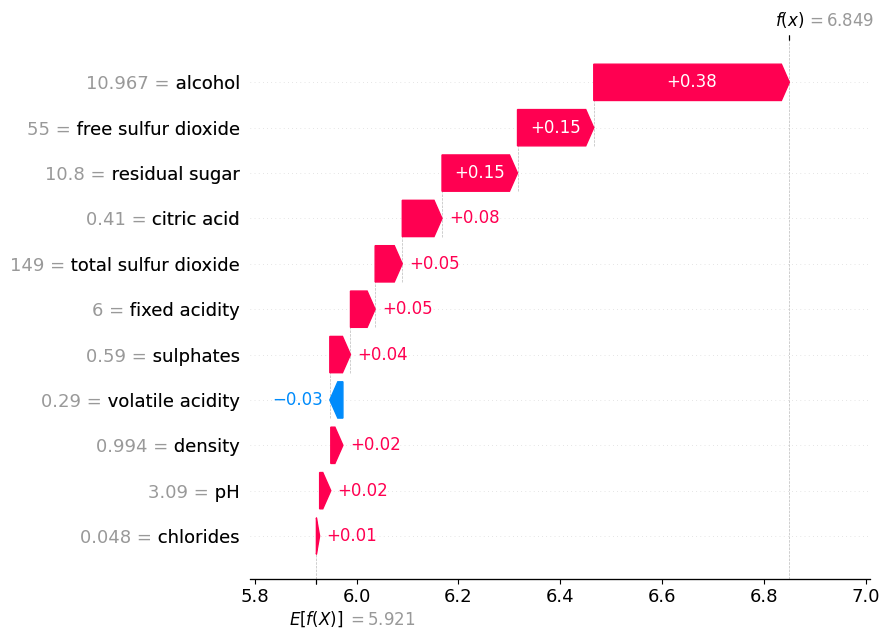

In [7]:
shap.plots.waterfall(shap_values[0], max_display=11)

### BEESWARM for GLOBAL SHAP interpretation
Possible to provide an overall view of how features influence (using SHAP) the model’s predictions.





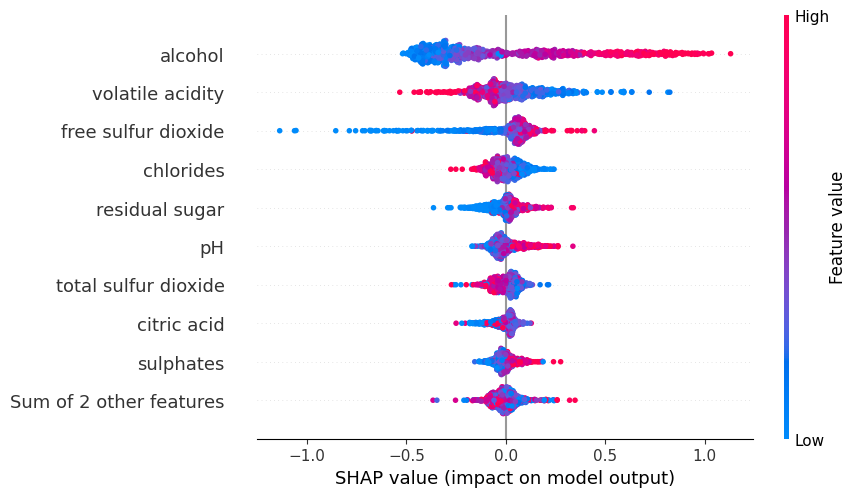

In [8]:
shap.plots.beeswarm(shap_values)

**SOME BASIC INTERPRETATIONS:** we see in beeswarm:
*  most inportant features: "alcohol" & "volatile"
* Low values for "free sulfur dioxide" resulting in lower quality.

### DEPENDENCE PLOT for explaining 1 feature GLOBAL SHAP


We see the relation between the two main important features:
* SHAP value of alcohol
* Values of alcohol
* Values of volatile acidity

By default, the shap dependence plot chooses the feature that has the strongest interaction with the feature of interest. In our case this is "volatile acidity".




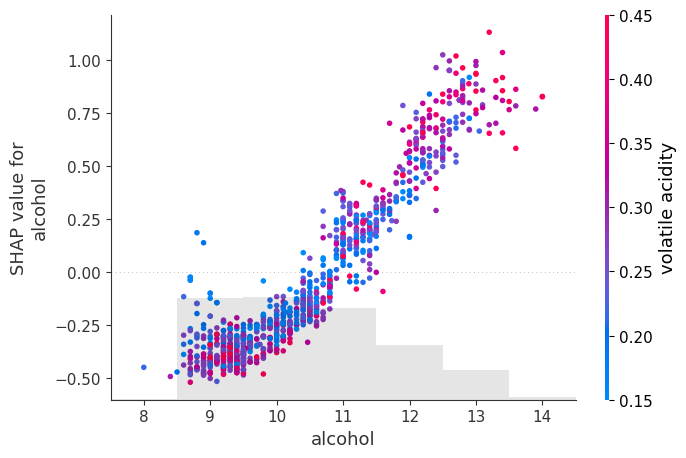

In [9]:
shap.plots.scatter(shap_values[:,"alcohol"], color=shap_values)

**SOME BASIC INTERPRETATIONS** of interaction plot:

* Higher alcohol level corresponds to a higher SHAP value
* Low volatile acidity reveals an interesting interaction with wines that have a low alcohol level
* The relationship reverses for wines with higher alcohol levels

